<a href="https://colab.research.google.com/github/abd500253-coder/Machine_Learning_Journey/blob/main/Logistic_Regression_Perceptron_Trick/Logistic_Regression_Perceptron_Trick.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression using the Perceptron Trick

This notebook implements a basic Logistic Regression classifier from scratch using numpy. Instead of standard Gradient Descent, we are implementing a stochastic update rule often referred to as the **Logistic Perceptron Trick**.

We will:
1. Define the **Sigmoid function** to map predictions to probabilities (0 to 1).
2. Implement the **update rule** to adjust our weights point-by-point based on the error.
3. Create a **classification function** applying a threshold to our probabilities.
4. Generate synthetic data and **visualize the decision boundary**.

In [1]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_probabilty(X, weights):
    z = np.dot(X, weights)
    return sigmoid(z)

def logistic_precptron_trick(X, y, epochs, learning_rate=0.01):
    # Initialize weights to ones
    weights = np.ones(X.shape[1])

    for i in range(epochs):
        for j in range(X.shape[0]):
            X_current = X[j]
            y_true = y[j]
            y_pred_prob = predict_probabilty(X_current, weights)

            # Calculate the error
            error = y_true - y_pred_prob

            # Update the weights
            weights += learning_rate * error * X_current

    return weights

def classify(X, weights, threshold=0.5):
    y_pred_prob = predict_probabilty(X, weights)
    y_pred = np.where(y_pred_prob >= threshold, 1, 0)
    return y_pred

## Generating Synthetic Data
To test our algorithm, we will create a linearly separable dataset using `sklearn.datasets`.

*Note: For the line equation $w_0 + w_1x_1 + w_2x_2 = 0$ to work correctly without forcing the line through the origin, we must add a "bias" term (a column of 1s) to our feature matrix `X`.*

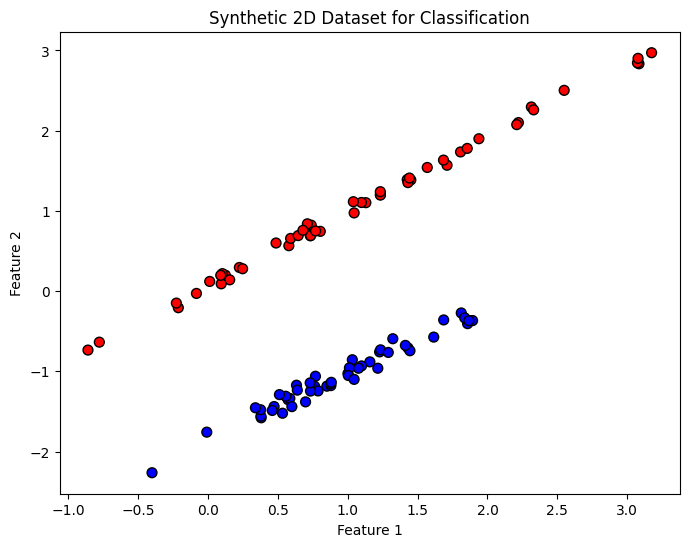

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# 1. Generate 100 samples with 2 features
X, y = make_classification(n_samples=100, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# 2. Add a bias term (a column of 1s) to X so our model can learn an intercept
X_with_bias = np.insert(X, 0, 1, axis=1)

# 3. Visualize the raw data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', s=50)
plt.title('Synthetic 2D Dataset for Classification')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## Training the Model
Now, we will pass our padded feature matrix and labels into our `logistic_precptron_trick` function to learn the optimal weights over 1,000 epochs. After training, we will evaluate the accuracy.

In [3]:
# Train the model
epochs = 1000
learning_rate = 0.1
weights = logistic_precptron_trick(X_with_bias, y, epochs, learning_rate)

print(f"Learned weights (Intercept, W1, W2): {weights}")

# Make predictions and calculate accuracy
predictions = classify(X_with_bias, weights)
accuracy = np.mean(predictions == y)
print(f"Training Accuracy: {accuracy * 100:.2f}%")

Learned weights (Intercept, W1, W2): [ 6.62024269 -6.574514    8.7094573 ]
Training Accuracy: 100.00%


## Visualizing the Decision Boundary
The decision boundary is the line where the probability is exactly 0.5.
In our mathematical formulation, this occurs when $z = 0$.
Therefore, our decision line formula is:
$$w_0 \cdot 1 + w_1 \cdot x_1 + w_2 \cdot x_2 = 0$$

To plot this on a 2D graph, we can solve for $x_2$ (which is our Y-axis):
$$x_2 = \frac{-(w_0 + w_1 \cdot x_1)}{w_2}$$

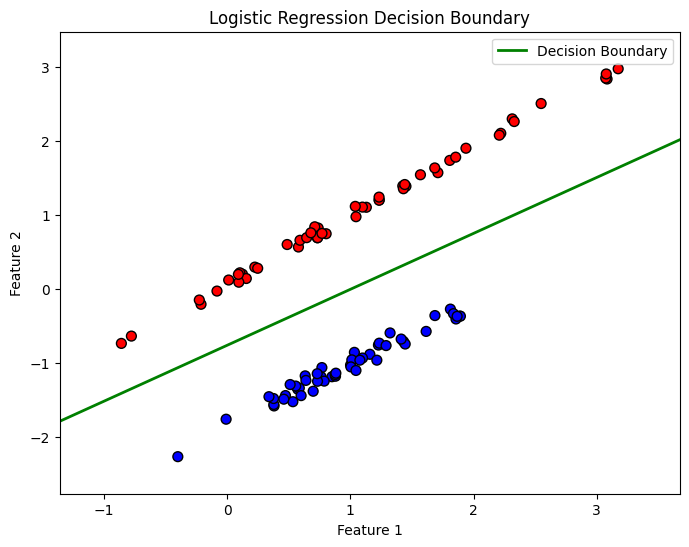

In [4]:
plt.figure(figsize=(8, 6))

# Plot the original data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', s=50)

# Calculate the decision boundary line
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x_line = np.linspace(x_min, x_max, 100)

# Extract weights: w0 is bias, w1 is feature 1 weight, w2 is feature 2 weight
w0, w1, w2 = weights[0], weights[1], weights[2]
y_line = -(w0 + w1 * x_line) / w2

# Plot the boundary
plt.plot(x_line, y_line, color='green', linewidth=2, label='Decision Boundary')

plt.xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()